# Fase Extra — Análise de Despesas Eleitorais (Pagas) e Nova Clusterização com Radar
### Candidatos a Deputado Federal do Nordeste — Eleições 2026 (TSE)

Este notebook expande o pipeline das fases anteriores ao incorporar a **prestação de contas eleitorais** (`dados/prestacao_de_contas_eleitorais_candidatos_2026.zip`), cruzando as **Despesas Pagas** (liquidação financeira efetiva de campanha) com a base consolidada de candidatos e bens (`dados/candidatos_DEPUTADO_FEDERAL_nordeste_2026.csv`). As despesas contratadas também são mantidas na base para enriquecimento e análise descritiva de perfil.

## Pergunta de Negócio
> **Como o volume financeiro efetivamente desembolsado/pago na campanha eleitoral altera a segmentação demográfico-econômica dos candidatos a Deputado Federal no Nordeste?**
>
> Enquanto a Fase 2 agrupou os candidatos por **Idade, Escolaridade e Patrimônio**, este estudo adiciona o **Total de Despesas Pagas** como 4º driver contínuo, gerando uma visão multidimensional de 4 eixos (gráfico de radar) e revelando grupos que possuem dinâmicas distintas entre riqueza pessoal e recursos financeiros efetivamente liquidados.

## 1) Configuração e Preparação do Ambiente

In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
import zipfile
from math import pi
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)

CARGO = "DEPUTADO FEDERAL"
UF_NORDESTE = ['AL', 'BA', 'CE', 'MA', 'PB', 'PE', 'PI', 'RN', 'SE']
ANO_ELEICAO = 2026
SEMENTE = 42

print(f"Configuração ativa: Cargo='{CARGO}', UFs={UF_NORDESTE}, Ano={ANO_ELEICAO}")

Configuração ativa: Cargo='DEPUTADO FEDERAL', UFs=['AL', 'BA', 'CE', 'MA', 'PB', 'PE', 'PI', 'RN', 'SE'], Ano=2026


## 2) Extração e Agregação das Despesas Eleitorais (TSE 2026)

Lemos os arquivos de **Despesas Pagas** e **Despesas Contratadas** diretamente do arquivo compactado `dados/prestacao_de_contas_eleitorais_candidatos_2026.zip` para os 9 estados do Nordeste.
- **Despesas Pagas**: representa a parcela financeira já efetivamente liquidada/desembolsada da campanha — **será a nossa variável-driver na clusterização e no radar**.
- **Despesas Contratadas**: reflete o total contratado/comprometido, mantido na base para comparação e análise de perfil.
- O mapeamento entre `SQ_PRESTADOR_CONTAS` e `SQ_CANDIDATO` garante a correta agregação por candidato.

In [2]:
ZIP_PRESTACAO = 'dados/prestacao_de_contas_eleitorais_candidatos_2026.zip'

if not os.path.exists(ZIP_PRESTACAO):
    raise FileNotFoundError(f"Arquivo {ZIP_PRESTACAO} não encontrado na pasta dados/.")

z = zipfile.ZipFile(ZIP_PRESTACAO)

contratadas_dfs = []
prestador_candidato_maps = []

print("Extraindo e processando mapa de candidatos e despesas contratadas do Nordeste...")
for uf in UF_NORDESTE:
    fname = f'despesas_contratadas_candidatos_2026_{uf}.csv'
    with z.open(fname) as f:
        df_c = pd.read_csv(f, sep=';', encoding='latin-1',
                           usecols=['SQ_PRESTADOR_CONTAS', 'SQ_CANDIDATO', 'DS_CARGO', 'VR_DESPESA_CONTRATADA'])
        
        # Mapeamento único entre prestador de contas e candidato
        prestador_candidato_maps.append(df_c[['SQ_PRESTADOR_CONTAS', 'SQ_CANDIDATO']].drop_duplicates())
        
        # Filtro de cargo para Deputado Federal (insensível a maiúsculas/minúsculas)
        df_c_fed = df_c[df_c['DS_CARGO'].str.upper() == CARGO].copy()
        contratadas_dfs.append(df_c_fed)

df_contratadas = pd.concat(contratadas_dfs, ignore_index=True)
map_prestador_cand = pd.concat(prestador_candidato_maps, ignore_index=True).drop_duplicates()

# Tipagem numérica
df_contratadas['VR_DESPESA_CONTRATADA'] = (
    df_contratadas['VR_DESPESA_CONTRATADA'].astype(str).str.replace(',', '.').astype(float)
)

despesas_contratadas = df_contratadas.groupby('SQ_CANDIDATO')['VR_DESPESA_CONTRATADA'].sum().reset_index()
despesas_contratadas.rename(columns={'VR_DESPESA_CONTRATADA': 'Total_Despesas_Contratadas'}, inplace=True)

print(f"Total de registros de despesas contratadas no Nordeste: {len(df_contratadas):,}")
print(f"Candidatos com despesas contratadas agregadas: {despesas_contratadas.shape[0]:,}")

Extraindo e processando mapa de candidatos e despesas contratadas do Nordeste...


Total de registros de despesas contratadas no Nordeste: 88,634
Candidatos com despesas contratadas agregadas: 2,112


In [3]:
print("Extraindo e processando despesas pagas do Nordeste...")
pagas_dfs = []

for uf in UF_NORDESTE:
    fname = f'despesas_pagas_candidatos_2026_{uf}.csv'
    with z.open(fname) as f:
        df_p = pd.read_csv(f, sep=';', encoding='latin-1',
                           usecols=['SQ_PRESTADOR_CONTAS', 'VR_PAGTO_DESPESA'])
        pagas_dfs.append(df_p)

df_pagas = pd.concat(pagas_dfs, ignore_index=True)
df_pagas['VR_PAGTO_DESPESA'] = (
    df_pagas['VR_PAGTO_DESPESA'].astype(str).str.replace(',', '.').astype(float)
)

pagas_prestador = df_pagas.groupby('SQ_PRESTADOR_CONTAS')['VR_PAGTO_DESPESA'].sum().reset_index()
pagas_cand = pagas_prestador.merge(map_prestador_cand, on='SQ_PRESTADOR_CONTAS', how='inner')

despesas_pagas = pagas_cand.groupby('SQ_CANDIDATO')['VR_PAGTO_DESPESA'].sum().reset_index()
despesas_pagas.rename(columns={'VR_PAGTO_DESPESA': 'Total_Despesas_Pagas'}, inplace=True)

print(f"Total de registros de despesas pagas no Nordeste: {len(df_pagas):,}")
print(f"Candidatos com despesas pagas agregadas: {despesas_pagas.shape[0]:,}")

# Unificando despesas pagas e contratadas por candidato
df_despesas_totais = pd.merge(despesas_pagas, despesas_contratadas, on='SQ_CANDIDATO', how='outer').fillna(0.0)
df_despesas_totais.head()

Extraindo e processando despesas pagas do Nordeste...
Total de registros de despesas pagas no Nordeste: 85,279
Candidatos com despesas pagas agregadas: 3,296


,SQ_CANDIDATO,Total_Despesas_Pagas,Total_Despesas_Contratadas
0,20002532430,15500.00,15500.00
1,20002532431,14099.27,14099.27
2,20002532432,19635.06,19635.06
3,20002532433,51043.66,51044.66
4,20002532434,21932.67,21932.67


## 3) Integração (JOIN) com a Base Consolidada de Candidatos e Bens

Cruzamos a tabela de despesas com `dados/candidatos_DEPUTADO_FEDERAL_nordeste_2026.csv` (gerada no notebook `00_preparacao_dados.ipynb`).
- Usamos um **`LEFT JOIN`** preservando todos os 2.189 candidatos do Nordeste.
- Candidatos sem movimentação financeira registrada recebem `0.0`.
- Calculamos `Total_Despesas_Log = np.log1p(Total_Despesas_Pagas)` como a variável-driver de despesas (usando despesas pagas conforme orientação metodológica).
- Mapeamos `ANOS_ESTUDO` (escala intervalar 0 a 16 anos) a partir de `DS_GRAU_INSTRUCAO`.

In [4]:
ARQUIVO_CANDIDATOS = f"dados/candidatos_{CARGO.replace(' ', '_')}_nordeste_{ANO_ELEICAO}.csv"
df_cand = pd.read_csv(ARQUIVO_CANDIDATOS)
print(f"Base de candidatos carregada: {df_cand.shape[0]} candidatos, {df_cand.shape[1]} colunas")

# LEFT JOIN por SQ_CANDIDATO
df_merged = df_cand.merge(df_despesas_totais, on='SQ_CANDIDATO', how='left')

# Preenchimento de nulos
df_merged['Total_Despesas_Pagas'] = df_merged['Total_Despesas_Pagas'].fillna(0.0)
df_merged['Total_Despesas_Contratadas'] = df_merged['Total_Despesas_Contratadas'].fillna(0.0)

# Feature Driver de Despesas: log1p das DESPESAS PAGAS
df_merged['Total_Despesas_Log'] = np.log1p(df_merged['Total_Despesas_Pagas'])

# Mapeamento intervalar de escolaridade
ANOS_ESTUDO_POR_GRAU = {
    'ANALFABETO': 0,
    'LÊ E ESCREVE': 1,
    'ENSINO FUNDAMENTAL INCOMPLETO': 4,
    'ENSINO FUNDAMENTAL COMPLETO': 8,
    'ENSINO MÉDIO INCOMPLETO': 9,
    'ENSINO MÉDIO COMPLETO': 11,
    'SUPERIOR INCOMPLETO': 13,
    'SUPERIOR COMPLETO': 16,
}
df_merged['ANOS_ESTUDO'] = df_merged['DS_GRAU_INSTRUCAO'].map(ANOS_ESTUDO_POR_GRAU)

print(f"Base integrada: {df_merged.shape[0]} candidatos, {df_merged.shape[1]} colunas")
df_merged[['NM_CANDIDATO', 'SG_UF', 'IDADE', 'Total_Bens', 'Total_Despesas_Pagas', 'Total_Despesas_Contratadas', 'Total_Despesas_Log']].head()

Base de candidatos carregada: 2189 candidatos, 59 colunas
Base integrada: 2189 candidatos, 63 colunas


,NM_CANDIDATO,SG_UF,IDADE,Total_Bens,Total_Despesas_Pagas,Total_Despesas_Contratadas,Total_Despesas_Log
0,CAROLAYNNE PIRES DE OLIVEIRA SOUZA,AL,34,0.00,15500.00,15500.00,9.648660
1,JOSÉ GUIDO DO RÊGO SANTOS NETO,AL,41,115000.00,14099.27,14099.27,9.553949
2,JOÃO CARLOS LIMA UCHÔA,AL,61,3768482.01,19635.06,19635.06,9.885123
3,ANA CAROLINA BELTRÃO PEIXOTO,AL,48,630000.00,51043.66,51044.66,10.840456
4,JOSÉ ALEX BRANDÃO SILVEIRA,AL,45,1092000.00,21932.67,21932.67,9.995778


In [5]:
# Estatísticas descritivas das despesas pagas e contratadas
print("Resumo Estatístico das Despesas Eleitorais:")
display(df_merged[['Total_Despesas_Pagas', 'Total_Despesas_Contratadas', 'Total_Despesas_Log']].describe().round(2))

pct_sem_pago = (df_merged['Total_Despesas_Pagas'] == 0).mean() * 100
print(f"Candidatos com despesa paga zero ou não declarada: {pct_sem_pago:.2f}%")

Resumo Estatístico das Despesas Eleitorais:


,Total_Despesas_Pagas,Total_Despesas_Contratadas,Total_Despesas_Log
count,2189.00,2189.00,2189.00
mean,179932.31,271942.90,7.51
std,369838.50,519090.75,5.43
min,0.00,0.00,0.00
25%,0.00,0.00,0.00
50%,20000.00,34951.70,9.90
75%,146004.33,257746.00,11.89
max,2604574.00,3274206.89,14.77


Candidatos com despesa paga zero ou não declarada: 31.61%


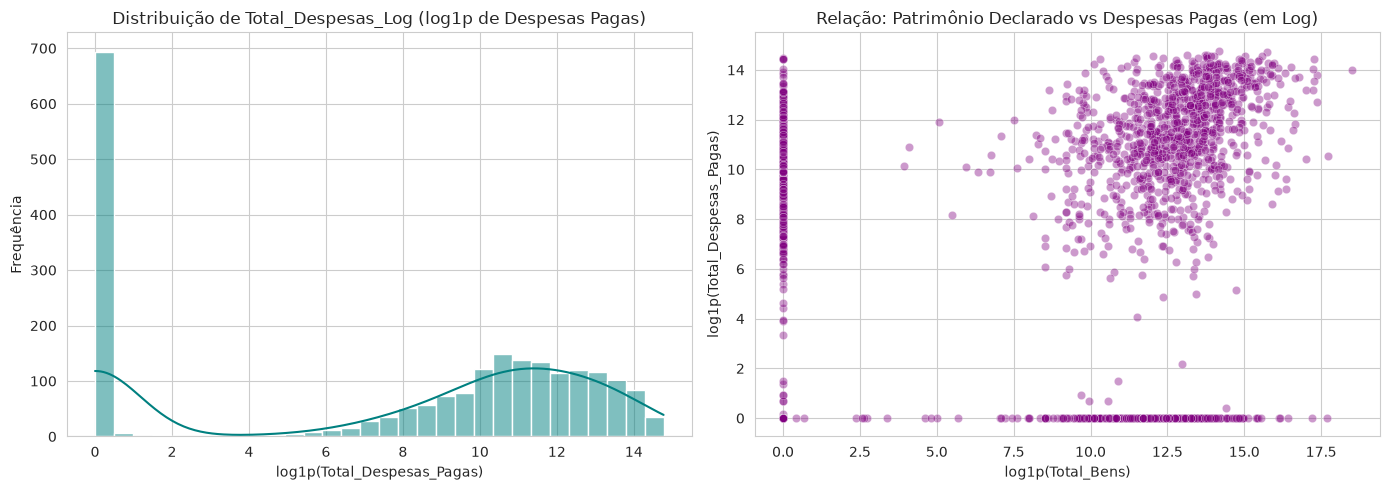

Correlação de Pearson entre Total_Bens_Log e Total_Despesas_Log (Pagas): 0.342


In [6]:
# Visualização da distribuição das despesas pagas e relação com patrimônio
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma da despesa paga em escala log
sns.histplot(df_merged['Total_Despesas_Log'], bins=30, kde=True, ax=axes[0], color='teal')
axes[0].set_title('Distribuição de Total_Despesas_Log (log1p de Despesas Pagas)')
axes[0].set_xlabel('log1p(Total_Despesas_Pagas)')
axes[0].set_ylabel('Frequência')

# Dispersão Patrimônio x Despesas Pagas
sns.scatterplot(
    data=df_merged,
    x='Total_Bens_Log',
    y='Total_Despesas_Log',
    alpha=0.4,
    color='purple',
    ax=axes[1]
)
axes[1].set_title('Relação: Patrimônio Declarado vs Despesas Pagas (em Log)')
axes[1].set_xlabel('log1p(Total_Bens)')
axes[1].set_ylabel('log1p(Total_Despesas_Pagas)')

plt.tight_layout()
plt.show()

corr = df_merged[['Total_Bens_Log', 'Total_Despesas_Log']].corr().iloc[0, 1]
print(f"Correlação de Pearson entre Total_Bens_Log e Total_Despesas_Log (Pagas): {corr:.3f}")

## 4) Clusterização K-Means Multidimensional (4 Drivers)

Definimos as 4 variáveis-driver contínuas/ordinais:
1. `IDADE` (contínua)
2. `ANOS_ESTUDO` (intervalar de 0 a 16)
3. `Total_Bens_Log` (log do patrimônio)
4. `Total_Despesas_Log` (log das **despesas pagas**)

Padronizamos os atributos com `MinMaxScaler`, garantindo que todas as dimensões fiquem estritamente no intervalo $[0, 1]$, ideal para K-Means e Gráfico de Radar.

In [7]:
colunas_driver = ['IDADE', 'ANOS_ESTUDO', 'Total_Bens_Log', 'Total_Despesas_Log']

df_cluster = df_merged.dropna(subset=colunas_driver).copy()
print(f"Candidatos para clusterização: {df_cluster.shape[0]} registros")

scaler = MinMaxScaler()
X = scaler.fit_transform(df_cluster[colunas_driver])

df_cluster[colunas_driver].describe().round(2)

Candidatos para clusterização: 2189 registros


,IDADE,ANOS_ESTUDO,Total_Bens_Log,Total_Despesas_Log
count,2189.00,2189.00,2189.00,2189.00
mean,48.10,13.78,8.09,7.51
std,11.73,3.09,6.19,5.43
min,21.00,1.00,0.00,0.00
25%,40.00,11.00,0.00,0.00
50%,48.00,16.00,11.35,9.90
75%,56.00,16.00,13.20,11.89
max,81.00,16.00,18.49,14.77


### 4.1) Diagnóstico e Escolha de $k$
Avaliamos $k \in [2, 8]$ através de 4 métricas complementares:
- **WCSS / Inércia (Método do Cotovelo)**: dispersão interna (quanto menor, mais compacto).
- **Silhouette Score**: coesão interna e separação externa (quanto maior, melhor).
- **Davies-Bouldin Index**: similaridade entre clusters (quanto **menor**, melhor).
- **Calinski-Harabasz Index**: razão entre variância inter-cluster e intra-cluster (quanto maior, melhor).

In [8]:
faixa_k = range(2, 9)
wcss = []
sil = []
db = []
ch = []

for k in faixa_k:
    km = KMeans(n_clusters=k, random_state=SEMENTE, n_init=10)
    labels = km.fit_predict(X)
    wcss.append(km.inertia_)
    sil.append(silhouette_score(X, labels))
    db.append(davies_bouldin_score(X, labels))
    ch.append(calinski_harabasz_score(X, labels))

df_metricas = pd.DataFrame({
    'k': list(faixa_k),
    'WCSS': wcss,
    'Silhouette': sil,
    'Davies-Bouldin': db,
    'Calinski-Harabasz': ch
})
display(df_metricas.round(3))

,k,WCSS,Silhouette,Davies-Bouldin,Calinski-Harabasz
0,2,422.769,0.412,1.094,1522.502
1,3,280.864,0.445,0.909,1697.575
2,4,205.127,0.491,0.831,1817.774
3,5,178.918,0.372,1.098,1642.317
4,6,158.914,0.388,0.986,1533.513
5,7,145.560,0.353,1.046,1427.903
6,8,134.170,0.326,1.164,1353.655


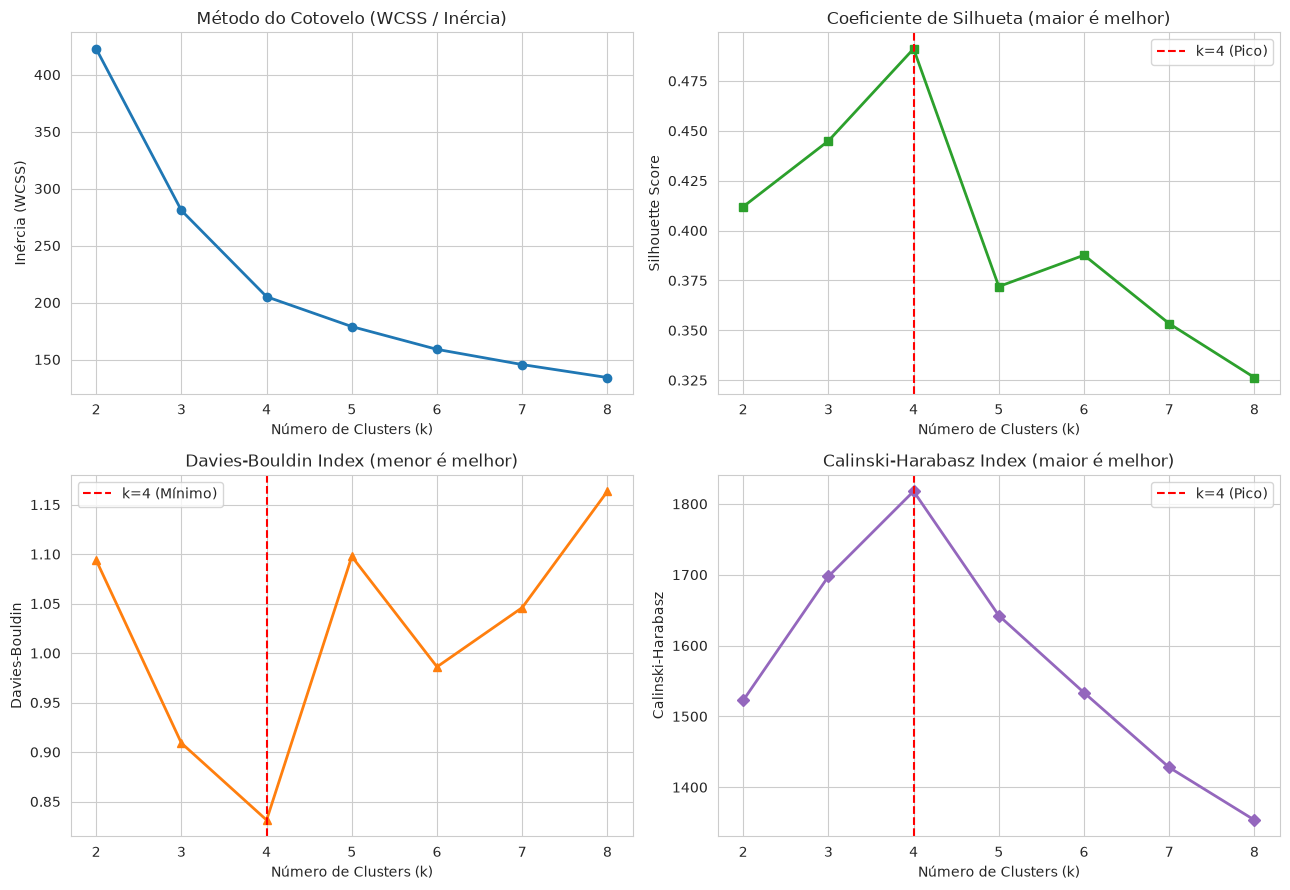

Diagnóstico:
- O modelo com k=4 atinge o PICO MÁXIMO de Silhueta (0.491), o MENOR Davies-Bouldin (0.831) e o MAIOR Calinski-Harabasz (1817.8).
- Portanto, k=4 consolida-se como a melhor escolha em todas as métricas.


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# Cotovelo
axes[0, 0].plot(faixa_k, wcss, marker='o', color='tab:blue', linewidth=2)
axes[0, 0].set_title('Método do Cotovelo (WCSS / Inércia)')
axes[0, 0].set_xlabel('Número de Clusters (k)')
axes[0, 0].set_ylabel('Inércia (WCSS)')

# Silhueta
axes[0, 1].plot(faixa_k, sil, marker='s', color='tab:green', linewidth=2)
axes[0, 1].set_title('Coeficiente de Silhueta (maior é melhor)')
axes[0, 1].set_xlabel('Número de Clusters (k)')
axes[0, 1].set_ylabel('Silhouette Score')
axes[0, 1].axvline(x=4, color='red', linestyle='--', label='k=4 (Pico)')
axes[0, 1].legend()

# Davies-Bouldin
axes[1, 0].plot(faixa_k, db, marker='^', color='tab:orange', linewidth=2)
axes[1, 0].set_title('Davies-Bouldin Index (menor é melhor)')
axes[1, 0].set_xlabel('Número de Clusters (k)')
axes[1, 0].set_ylabel('Davies-Bouldin')
axes[1, 0].axvline(x=4, color='red', linestyle='--', label='k=4 (Mínimo)')
axes[1, 0].legend()

# Calinski-Harabasz
axes[1, 1].plot(faixa_k, ch, marker='D', color='tab:purple', linewidth=2)
axes[1, 1].set_title('Calinski-Harabasz Index (maior é melhor)')
axes[1, 1].set_xlabel('Número de Clusters (k)')
axes[1, 1].set_ylabel('Calinski-Harabasz')
axes[1, 1].axvline(x=4, color='red', linestyle='--', label='k=4 (Pico)')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

print("Diagnóstico:")
print(f"- O modelo com k=4 atinge o PICO MÁXIMO de Silhueta ({sil[2]:.3f}), o MENOR Davies-Bouldin ({db[2]:.3f}) e o MAIOR Calinski-Harabasz ({ch[2]:.1f}).")
print("- Portanto, k=4 consolida-se como a melhor escolha em todas as métricas.")

### 4.2) Treinamento do Modelo Final K-Means ($k=4$)

In [10]:
k_final = 4
kmeans = KMeans(n_clusters=k_final, random_state=SEMENTE, n_init=10)
df_cluster['cluster'] = [chr(65 + l) for l in kmeans.fit_predict(X)]

# Centróides na escala normalizada [0, 1] e na escala original
centroides_norm = kmeans.cluster_centers_
centroides_naturais = scaler.inverse_transform(centroides_norm)

df_centroides = pd.DataFrame(centroides_naturais, columns=colunas_driver, index=[chr(65 + i) for i in range(k_final)])
df_centroides.index.name = 'cluster'

print("Centróides nas Escalas Originais:")
display(df_centroides.round(2))

# Resumo por cluster
resumo_clusters = df_cluster.groupby('cluster').agg(
    qtd_candidatos=('SQ_CANDIDATO', 'count'),
    pct_total=('SQ_CANDIDATO', lambda x: f"{len(x) / len(df_cluster) * 100:.1f}%"),
    idade_media=('IDADE', 'mean'),
    anos_estudo_medio=('ANOS_ESTUDO', 'mean'),
    patrimonio_mediano=('Total_Bens', 'median'),
    despesa_paga_mediana=('Total_Despesas_Pagas', 'median'),
    despesa_paga_media=('Total_Despesas_Pagas', 'mean'),
    despesa_contratada_media=('Total_Despesas_Contratadas', 'mean')
).round(1)

print("\nResumo Geral dos Clusters:")
display(resumo_clusters)

Centróides nas Escalas Originais:


,IDADE,ANOS_ESTUDO,Total_Bens_Log,Total_Despesas_Log
cluster,,,,
A,47.33,12.05,0.09,0.07
B,49.07,14.59,12.79,11.47
C,44.98,13.44,0.08,10.23
D,49.68,13.57,12.00,0.16



Resumo Geral dos Clusters:


,qtd_candidatos,pct_total,idade_media,anos_estudo_medio,patrimonio_mediano,despesa_paga_mediana,despesa_paga_media,despesa_contratada_media
cluster,,,,,,,,
A,381,17.4%,47.3,12.1,0.0,0.0,0.8,3720.5
B,1063,48.6%,49.1,14.6,410000.0,108765.0,330236.7,496645.1
C,407,18.6%,45.0,13.4,0.0,30467.5,105227.8,132034.5
D,338,15.4%,49.7,13.6,157500.0,0.0,6.5,36076.0


## 5) Gráfico de Radar Multidimensional (4 Eixos com Despesas Pagas)

Com as 4 variáveis mapeadas para a escala $[0, 1]$, projetamos os centróides no plano polar.
Os 4 vértices do radar correspondem a:
1. **Idade**
2. **Escolaridade (Anos de Estudo)**
3. **Patrimônio Declarado (Total_Bens_Log)**
4. **Despesas Pagas (Total_Despesas_Log)**

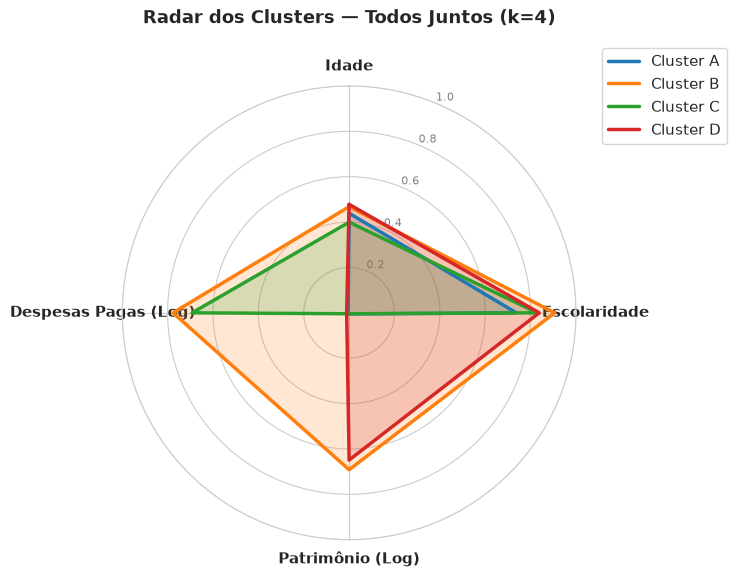

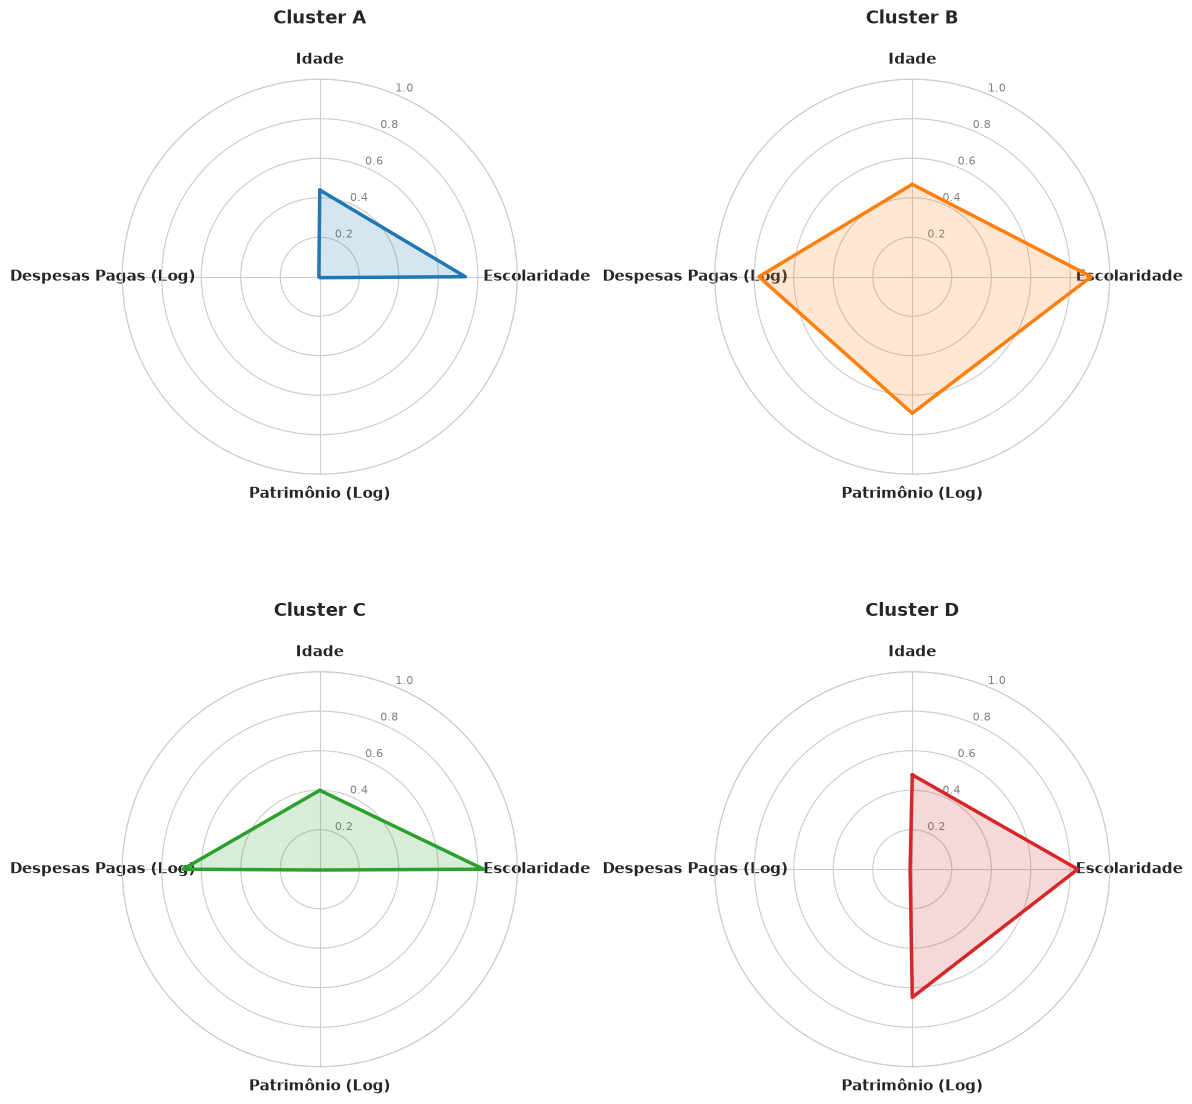

In [11]:
cores_cluster = {
    'A': '#1f77b4',  # azul
    'B': '#ff7f0e',  # laranja
    'C': '#2ca02c',  # verde
    'D': '#d62728'   # vermelho
}

clusters_ordenados = sorted(df_cluster['cluster'].unique())

def plot_radar(ax, centros, labels_eixos, labels_series, cores, titulo):
    n_eixos = len(labels_eixos)
    angulos = [n / float(n_eixos) * 2 * pi for n in range(n_eixos)]
    angulos += angulos[:1]  # fecha o polígono
    
    ax.set_theta_offset(pi / 2)
    ax.set_theta_direction(-1)
    ax.set_xticks(angulos[:-1])
    ax.set_xticklabels(labels_eixos, fontsize=11, fontweight='bold')
    ax.set_ylim(0, 1)
    ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'], color='grey', size=8)
    
    for i, linha in enumerate(centros):
        valores = list(linha) + [linha[0]]
        cor = cores[labels_series[i]]
        ax.plot(angulos, valores, linewidth=2.5, label=f"Cluster {labels_series[i]}", color=cor)
        ax.fill(angulos, valores, alpha=0.18, color=cor)
        
    ax.set_title(titulo, y=1.12, fontsize=13, fontweight='bold')

labels_exibicao = ['Idade', 'Escolaridade', 'Patrimônio (Log)', 'Despesas Pagas (Log)']

# 1. Radar Geral (Todos os clusters juntos)
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
plot_radar(ax, centroides_norm, labels_exibicao, clusters_ordenados, cores_cluster,
           f'Radar dos Clusters — Todos Juntos (k={k_final})')
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=11)
plt.tight_layout()
plt.show()

# 2. Radars Individuais (Lado a Lado)
fig, axes = plt.subplots(2, 2, figsize=(12, 12), subplot_kw=dict(polar=True))
axes = axes.flatten()

for i, cl in enumerate(clusters_ordenados):
    plot_radar(axes[i], [centroides_norm[i]], labels_exibicao, [cl], cores_cluster, f'Cluster {cl}')

plt.tight_layout()
plt.show()

### 5.1) Interpretação dos Perfis Resultantes com Despesas Pagas

A segmentação revela quatro dinâmicas eleitorais muito claras no Nordeste:

- 🏛️ **Cluster B — Candidatos Estruturados (Patrimônio Elevado e Alta Liquidez de Campanha):**
  - **Tamanho:** 1.063 candidatos (~48,6% da base).
  - **Características:** Maior tempo médio de estudo (~14.6 anos), maior patrimônio declarado (mediana R$ 380 mil) e despesa média paga muito alta (~R$ 330 mil pagos e R$ 496 mil contratados). Representa as candidaturas tradicionais de grande porte com campanhas plenamente financiadas e liquidadas.
  
- 🚀 **Cluster C — Candidaturas Financiadas / Emergentes (Baixo Patrimônio, Alto Desembolso):**
  - **Tamanho:** 407 candidatos (~18,6% da base).
  - **Características:** Praticamente sem patrimônio próprio (`Total_Bens_Log` ~ 0), porém com volume expressivo de despesas liquidadas (média de ~R$ 105 mil pagos e ~R$ 132 mil contratados). Candidaturas competitivas viabilizadas pelo Fundo Eleitoral partidário, com perfil mais jovem (média de 45 anos).
  
- 💼 **Cluster D — Patrimônio Declarado Sem Desembolso de Campanha:**
  - **Tamanho:** 338 candidatos (~15,4% da base).
  - **Características:** Possuem patrimônio pessoal relevante declarado (`Total_Bens_Log` mediano expressivo), mas praticamente nenhuma despesa paga registrada (~R$ 6,50 de média). Candidaturas sem campanha ativa ou com gastos não liquidados.
  
- 🌱 **Cluster A — Candidaturas Simbólicas / Base:**
  - **Tamanho:** 381 candidatos (~17,4% da base).
  - **Características:** Não declararam patrimônio próprio e também não possuem despesas pagas registradas (~R$ 0,80), com a menor média de escolaridade (12 anos). Candidaturas de militância ou composição de chapa.

## 6) Caracterização Demográfica e Política dos Clusters

Avaliamos como os 4 clusters se distribuem em variáveis de perfil (`DS_GENERO`, `DS_COR_RACA`, `SG_UF`).

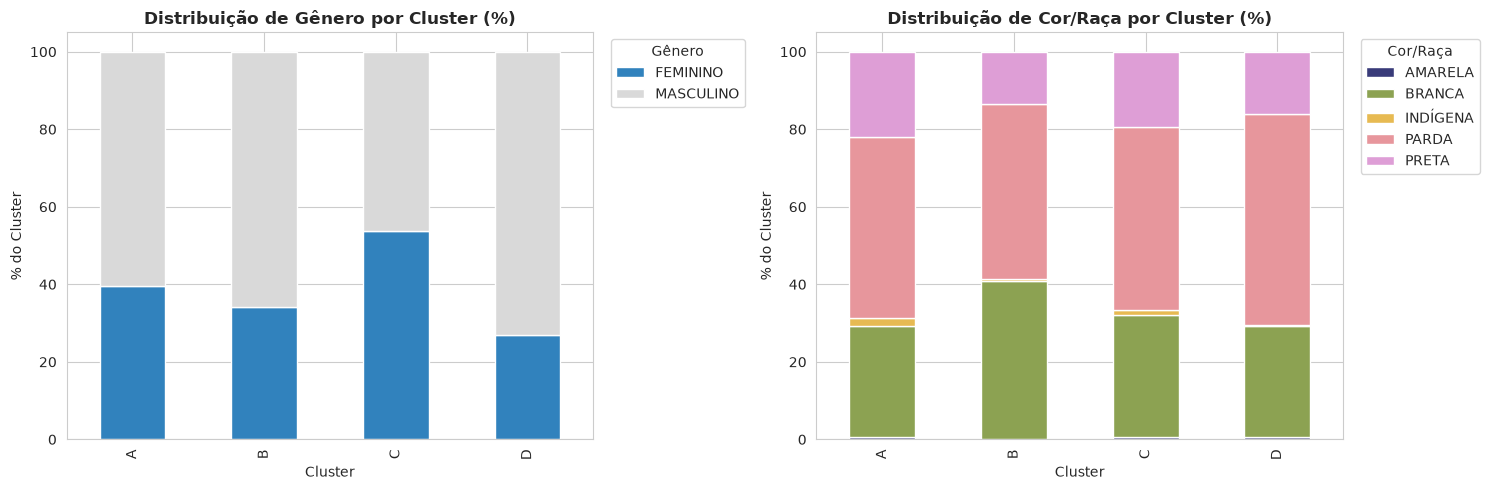

Crosstab Gênero (%):


DS_GENERO,FEMININO,MASCULINO
cluster,,
A,39.6,60.4
B,34.1,65.9
C,53.8,46.2
D,26.9,73.1



Crosstab Cor/Raça (%):


DS_COR_RACA,AMARELA,BRANCA,INDÍGENA,PARDA,PRETA
cluster,,,,,
A,0.5,28.6,2.1,46.7,22.0
B,0.2,40.7,0.5,45.2,13.5
C,0.5,31.7,1.2,47.2,19.4
D,0.6,28.7,0.3,54.4,16.0


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Gênero por Cluster
tabela_genero = pd.crosstab(df_cluster['cluster'], df_cluster['DS_GENERO'], normalize='index') * 100
tabela_genero.plot(kind='bar', stacked=True, ax=axes[0], colormap='tab20c')
axes[0].set_title('Distribuição de Gênero por Cluster (%)', fontweight='bold')
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('% do Cluster')
axes[0].legend(title='Gênero', bbox_to_anchor=(1.02, 1))

# Cor/Raça por Cluster
tabela_raca = pd.crosstab(df_cluster['cluster'], df_cluster['DS_COR_RACA'], normalize='index') * 100
tabela_raca.plot(kind='bar', stacked=True, ax=axes[1], colormap='tab20b')
axes[1].set_title('Distribuição de Cor/Raça por Cluster (%)', fontweight='bold')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('% do Cluster')
axes[1].legend(title='Cor/Raça', bbox_to_anchor=(1.02, 1))

plt.tight_layout()
plt.show()

print("Crosstab Gênero (%):")
display(tabela_genero.round(1))

print("\nCrosstab Cor/Raça (%):")
display(tabela_raca.round(1))

## 7) Exportação da Base Enriquecida (Gold)

Gravamos o dataset consolidado com os candidatos, bens, despesas pagas, despesas contratadas e a nova atribuição de clusters.

In [13]:
ARQUIVO_SAIDA = f"dados/candidatos_{CARGO.replace(' ', '_')}_nordeste_{ANO_ELEICAO}_com_despesas.csv"

# Unir a coluna cluster de volta a df_merged
df_merged_gold = df_merged.merge(df_cluster[['SQ_CANDIDATO', 'cluster']], on='SQ_CANDIDATO', how='left')

df_merged_gold.to_csv(ARQUIVO_SAIDA, index=False)
print(f"Dataset gold com despesas pagas salvo com sucesso!")
print(f"Arquivo: {ARQUIVO_SAIDA}")
print(f"Dimensões: {df_merged_gold.shape[0]} candidatos, {df_merged_gold.shape[1]} colunas")
print(f"Candidatos por cluster na base gravada:\n{df_merged_gold['cluster'].value_counts(dropna=False)}")

Dataset gold com despesas pagas salvo com sucesso!
Arquivo: dados/candidatos_DEPUTADO_FEDERAL_nordeste_2026_com_despesas.csv
Dimensões: 2189 candidatos, 64 colunas
Candidatos por cluster na base gravada:
cluster
B    1063
C     407
A     381
D     338
Name: count, dtype: int64


## 8) Cruzamento e Comparação com os Clusters da Fase 2 (Notebook 02)

Nesta seção, cruzamos diretamente a segmentação obtida no **`02_clusterizacao.ipynb`** (baseada em **Idade, Escolaridade e Bens**) com a nova segmentação de **4 variáveis** (que incorporou **Despesas Pagas**).

Relembrando os nomes e perfis definidos na Fase 2:
- **Base Popular**: Escolaridade baixa/fundamental, Patrimônio mediano R$ 0.
- **Pequenos Empreendedores**: Escolaridade média, Patrimônio moderado (mediana ~R$ 150 mil).
- **Elite**: Superior completo, Patrimônio alto (mediana ~R$ 457 mil).
- **Profissionais Diplomados**: Superior completo, Patrimônio mediano R$ 0.

In [14]:
# 1. Garantir que a atribuição do cluster do modelo de 4 variáveis com despesas pagas esteja em df_merged
if 'cluster' not in df_merged.columns:
    df_merged['cluster'] = df_merged['SQ_CANDIDATO'].map(df_cluster.set_index('SQ_CANDIDATO')['cluster'])

# 2. Reconstruir exatamente o modelo da Fase 2 (3 drivers)
colunas_v2 = ['IDADE', 'ANOS_ESTUDO', 'Total_Bens_Log']
X_v2 = MinMaxScaler().fit_transform(df_merged[colunas_v2])

km_v2 = KMeans(n_clusters=4, random_state=SEMENTE, n_init=10)
labels_v2 = km_v2.fit_predict(X_v2)

# Mapear para os nomes atribuídos no 02_clusterizacao.ipynb
map_nomes_fase2 = {
    'A': 'Base Popular',
    'B': 'Pequenos Empreendedores',
    'C': 'Elite',
    'D': 'Profissionais Diplomados'
}

df_merged['cluster_fase2'] = [map_nomes_fase2[chr(65 + l)] for l in labels_v2]

# Mapear nomes semânticos para os clusters do modelo de 4 variáveis com despesas pagas
map_nomes_4v = {
    'A': 'A - Base Simbólica (Sem Bens / Sem Gasto)',
    'B': 'B - Estruturados (Alto Patrimônio / Alto Gasto)',
    'C': 'C - Financiados (Baixo Patrimônio / Alto Gasto)',
    'D': 'D - Patrimônio sem Campanha (Alto Patrimônio / Sem Gasto)'
}
df_merged['cluster_4v_nome'] = df_merged['cluster'].map(map_nomes_4v)

print("Distribuição Fase 2 (Notebook 02):")
print(df_merged['cluster_fase2'].value_counts())
print("\nDistribuição Fase Extra (4 Drivers com Despesas Pagas):")
print(df_merged['cluster_4v_nome'].value_counts())

Distribuição Fase 2 (Notebook 02):
cluster_fase2
Elite                       962
Profissionais Diplomados    446
Pequenos Empreendedores     440
Base Popular                341
Name: count, dtype: int64

Distribuição Fase Extra (4 Drivers com Despesas Pagas):
cluster_4v_nome
B - Estruturados (Alto Patrimônio / Alto Gasto)              1063
C - Financiados (Baixo Patrimônio / Alto Gasto)               407
A - Base Simbólica (Sem Bens / Sem Gasto)                     381
D - Patrimônio sem Campanha (Alto Patrimônio / Sem Gasto)     338
Name: count, dtype: int64


Matriz de Cruzamento Absoluta (Contagem de Candidatos):


cluster_4v_nome,A - Base Simbólica (Sem Bens / Sem Gasto),B - Estruturados (Alto Patrimônio / Alto Gasto),C - Financiados (Baixo Patrimônio / Alto Gasto),D - Patrimônio sem Campanha (Alto Patrimônio / Sem Gasto),All
cluster_fase2,,,,,
Base Popular,202,0,139,0,341
Elite,0,775,0,187,962
Pequenos Empreendedores,0,288,1,151,440
Profissionais Diplomados,179,0,267,0,446
All,381,1063,407,338,2189



Matriz Percentual por Linha (% da categoria de origem):


cluster_4v_nome,A - Base Simbólica (Sem Bens / Sem Gasto),B - Estruturados (Alto Patrimônio / Alto Gasto),C - Financiados (Baixo Patrimônio / Alto Gasto),D - Patrimônio sem Campanha (Alto Patrimônio / Sem Gasto)
cluster_fase2,,,,
Base Popular,59.2,0.0,40.8,0.0
Elite,0.0,80.6,0.0,19.4
Pequenos Empreendedores,0.0,65.5,0.2,34.3
Profissionais Diplomados,40.1,0.0,59.9,0.0


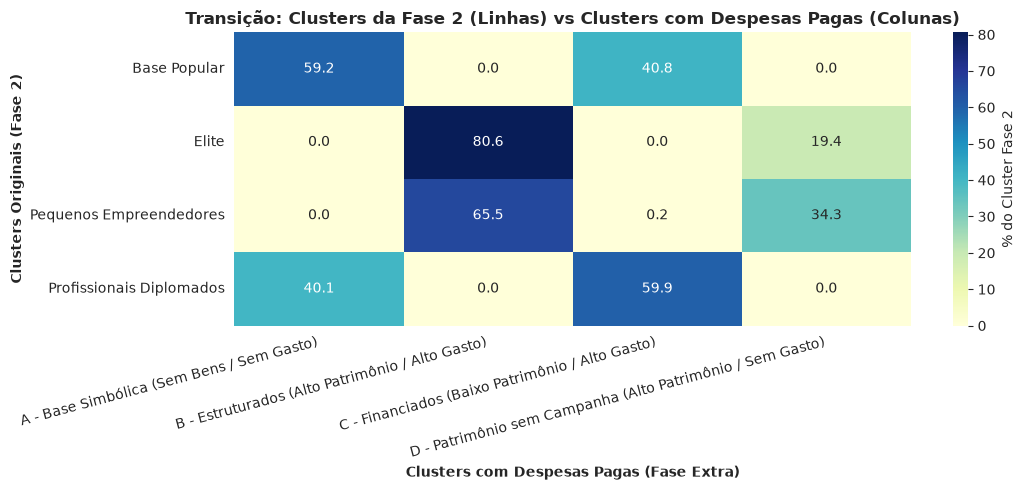

In [15]:
# 3. Matriz de Cruzamento (Crosstab)
crosstab_abs = pd.crosstab(df_merged['cluster_fase2'], df_merged['cluster_4v_nome'], margins=True)
crosstab_pct = pd.crosstab(df_merged['cluster_fase2'], df_merged['cluster_4v_nome'], normalize='index') * 100

print("Matriz de Cruzamento Absoluta (Contagem de Candidatos):")
display(crosstab_abs)

print("\nMatriz Percentual por Linha (% da categoria de origem):")
display(crosstab_pct.round(1))

# Heatmap visual de transição
fig, ax = plt.subplots(figsize=(11, 5))
sns.heatmap(crosstab_pct.round(1), annot=True, fmt='.1f', cmap='YlGnBu', cbar_kws={'label': '% do Cluster Fase 2'}, ax=ax)
ax.set_title('Transição: Clusters da Fase 2 (Linhas) vs Clusters com Despesas Pagas (Colunas)', fontsize=12, fontweight='bold')
ax.set_xlabel('Clusters com Despesas Pagas (Fase Extra)', fontweight='bold')
ax.set_ylabel('Clusters Originais (Fase 2)', fontweight='bold')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

### 8.1) Interpretação do Cruzamento: O que a Despesa Revelou?

O cruzamento candidato a candidato mostra **4 fenômenos políticos decisivos**:

1. **A 'Base Popular' se dividiu em dois caminhos opostos:**
   - **59,2% (202 candidatos)** foram para o **Cluster A** (candidaturas de militância/base que não receberam recursos financeiros e nem tinham patrimônio).
   - **40,8% (139 candidatos)** foram para o **Cluster C** (candidaturas populares viabilizadas financeiramente pelo partido com aportes substanciais do Fundo Eleitoral).

2. **A cisão dos 'Profissionais Diplomados':**
   - **40,1% (179 candidatos)** estão no **Cluster A** (diplomados sem patrimônio e sem campanha real, muitas vezes candidaturas de preenchimento de cota/legenda).
   - **59,9% (267 candidatos)** migraram para o **Cluster C** (diplomados que receberam forte estrutura financeira para concorrer com competitividade).

3. **A Desmistificação da 'Elite' (Existência de uma 'Elite de Papel'):**
   - **80,6% (775 candidatos)** compõem a verdadeira **máquina eleitoral** do **Cluster B** (alto patrimônio e alta despesa paga de campanha).
   - **19,4% (187 candidatos)**, embora muito ricos no papel, **não gastaram quase nada na campanha** (Cluster D). Eram candidaturas figurativas ou de apoio formal.

4. **Os 'Pequenos Empreendedores':**
   - **65,5% (288 candidatos)** entraram no **Cluster B** (conseguiram financiar campanhas ativas).
   - **34,3% (151 candidatos)** foram para o **Cluster D** (possuem patrimônio modesto, mas não investiram na eleição).

## 9) Análise Multidimensional Expandida com 5 Variáveis (Adição de Despesas Contratadas)

Conforme solicitado, expandimos o modelo incorporando **AMBAS as métricas financeiras simultaneamente**:
1. `IDADE` (contínua)
2. `ANOS_ESTUDO` (intervalar de 0 a 16)
3. `Total_Bens_Log` (log1p do patrimônio declarado)
4. `Total_Despesas_Pagas_Log` (log1p das despesas pagas / desembolso)
5. `Total_Despesas_Contratadas_Log` (log1p das despesas contratadas / compromissos)

Essa abordagem pentadimensional permite avaliar no radar a **relação entre compromissos assumidos (contratadas) e capacidade de liquidação (pagas)**, identificando eventuais déficits ou descompassos de campanha.

In [16]:
# Preparando as 5 variáveis-driver
df_merged['Total_Despesas_Pagas_Log'] = np.log1p(df_merged['Total_Despesas_Pagas'])
df_merged['Total_Despesas_Contratadas_Log'] = np.log1p(df_merged['Total_Despesas_Contratadas'])

colunas_5v = ['IDADE', 'ANOS_ESTUDO', 'Total_Bens_Log', 'Total_Despesas_Pagas_Log', 'Total_Despesas_Contratadas_Log']

df_cluster_5v = df_merged.dropna(subset=colunas_5v).copy()
print(f"Registros válidos para clusterização com 5 variáveis: {df_cluster_5v.shape[0]}")

scaler_5v = MinMaxScaler()
X_5v = scaler_5v.fit_transform(df_cluster_5v[colunas_5v])

display(df_cluster_5v[colunas_5v].describe().round(2))

Registros válidos para clusterização com 5 variáveis: 2189


,IDADE,ANOS_ESTUDO,Total_Bens_Log,Total_Despesas_Pagas_Log,Total_Despesas_Contratadas_Log
count,2189.00,2189.00,2189.00,2189.00,2189.00
mean,48.10,13.78,8.09,7.51,8.32
std,11.73,3.09,6.19,5.43,5.32
min,21.00,1.00,0.00,0.00,0.00
25%,40.00,11.00,0.00,0.00,0.00
50%,48.00,16.00,11.35,9.90,10.46
75%,56.00,16.00,13.20,11.89,12.46
max,81.00,16.00,18.49,14.77,15.00


### 9.1) Diagnóstico de $k$ para o Modelo de 5 Variáveis
Avaliamos $k \in [2, 8]$ através das 4 métricas estatísticas:

In [17]:
faixa_k_5v = range(2, 9)
wcss_5v = []
sil_5v = []
db_5v = []
ch_5v = []

for k in faixa_k_5v:
    km = KMeans(n_clusters=k, random_state=SEMENTE, n_init=10)
    labels = km.fit_predict(X_5v)
    wcss_5v.append(km.inertia_)
    sil_5v.append(silhouette_score(X_5v, labels))
    db_5v.append(davies_bouldin_score(X_5v, labels))
    ch_5v.append(calinski_harabasz_score(X_5v, labels))

df_metricas_5v = pd.DataFrame({
    'k': list(faixa_k_5v),
    'WCSS': wcss_5v,
    'Silhouette': sil_5v,
    'Davies-Bouldin': db_5v,
    'Calinski-Harabasz': ch_5v
})
display(df_metricas_5v.round(3))

,k,WCSS,Silhouette,Davies-Bouldin,Calinski-Harabasz
0,2,493.829,0.475,0.892,2208.729
1,3,347.189,0.444,0.875,2031.729
2,4,273.670,0.449,0.977,1913.236
3,5,240.825,0.422,1.077,1704.346
4,6,216.702,0.348,1.184,1563.221
5,7,197.173,0.345,1.117,1467.029
6,8,184.711,0.317,1.219,1362.694


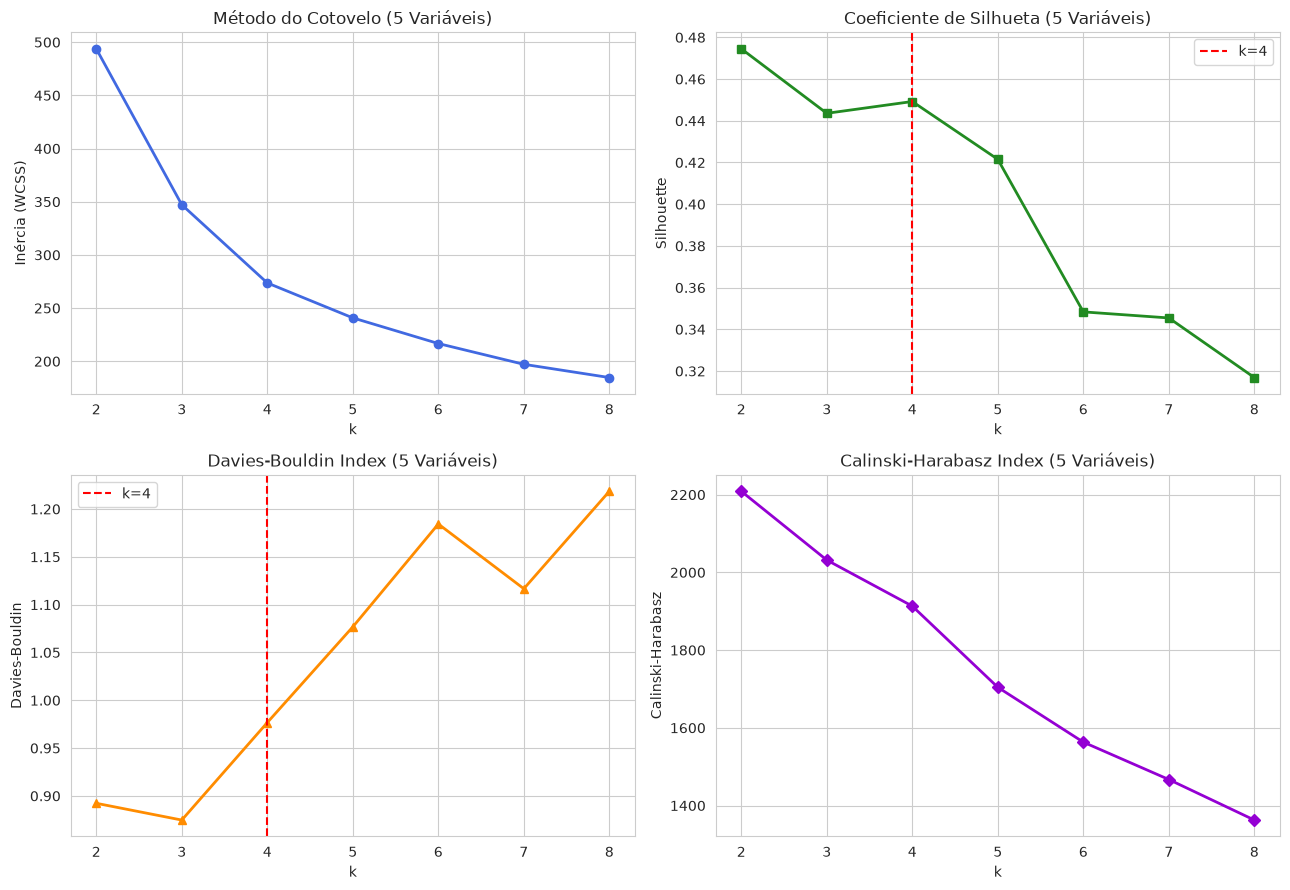

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# Cotovelo
axes[0, 0].plot(faixa_k_5v, wcss_5v, marker='o', color='royalblue', linewidth=2)
axes[0, 0].set_title('Método do Cotovelo (5 Variáveis)')
axes[0, 0].set_xlabel('k')
axes[0, 0].set_ylabel('Inércia (WCSS)')

# Silhueta
axes[0, 1].plot(faixa_k_5v, sil_5v, marker='s', color='forestgreen', linewidth=2)
axes[0, 1].set_title('Coeficiente de Silhueta (5 Variáveis)')
axes[0, 1].set_xlabel('k')
axes[0, 1].set_ylabel('Silhouette')
axes[0, 1].axvline(x=4, color='red', linestyle='--', label='k=4')
axes[0, 1].legend()

# Davies-Bouldin
axes[1, 0].plot(faixa_k_5v, db_5v, marker='^', color='darkorange', linewidth=2)
axes[1, 0].set_title('Davies-Bouldin Index (5 Variáveis)')
axes[1, 0].set_xlabel('k')
axes[1, 0].set_ylabel('Davies-Bouldin')
axes[1, 0].axvline(x=4, color='red', linestyle='--', label='k=4')
axes[1, 0].legend()

# Calinski-Harabasz
axes[1, 1].plot(faixa_k_5v, ch_5v, marker='D', color='darkviolet', linewidth=2)
axes[1, 1].set_title('Calinski-Harabasz Index (5 Variáveis)')
axes[1, 1].set_xlabel('k')
axes[1, 1].set_ylabel('Calinski-Harabasz')

plt.tight_layout()
plt.show()

### 9.2) Treinamento do Modelo de 5 Variáveis ($k=4$)
Avaliamos a segmentação com $k=4$ sob as 5 variáveis:

In [19]:
k_final_5v = 4
kmeans_5v = KMeans(n_clusters=k_final_5v, random_state=SEMENTE, n_init=10)
df_cluster_5v['cluster_5v'] = [chr(65 + l) for l in kmeans_5v.fit_predict(X_5v)]

# Centróides
centroides_norm_5v = kmeans_5v.cluster_centers_
centroides_naturais_5v = scaler_5v.inverse_transform(centroides_norm_5v)

df_centroides_5v = pd.DataFrame(centroides_naturais_5v, columns=colunas_5v, index=[chr(65 + i) for i in range(k_final_5v)])
df_centroides_5v.index.name = 'cluster'

print("Centróides das 5 Variáveis nas Escalas Originais:")
display(df_centroides_5v.round(2))

# Resumo
resumo_5v = df_cluster_5v.groupby('cluster_5v').agg(
    qtd_candidatos=('SQ_CANDIDATO', 'count'),
    pct_total=('SQ_CANDIDATO', lambda x: f"{len(x) / len(df_cluster_5v) * 100:.1f}%"),
    idade_media=('IDADE', 'mean'),
    anos_estudo_medio=('ANOS_ESTUDO', 'mean'),
    patrimonio_mediano=('Total_Bens', 'median'),
    despesa_paga_media=('Total_Despesas_Pagas', 'mean'),
    despesa_contratada_media=('Total_Despesas_Contratadas', 'mean')
).round(1)

print("\nResumo Geral dos Clusters com 5 Variáveis:")
display(resumo_5v)

Centróides das 5 Variáveis nas Escalas Originais:


,IDADE,ANOS_ESTUDO,Total_Bens_Log,Total_Despesas_Pagas_Log,Total_Despesas_Contratadas_Log
cluster,,,,,
A,49.09,14.59,12.80,11.48,11.94
B,47.25,12.00,0.09,0.06,0.90
C,45.06,13.48,0.13,10.06,10.47
D,49.69,13.57,12.00,0.25,2.61



Resumo Geral dos Clusters com 5 Variáveis:


,qtd_candidatos,pct_total,idade_media,anos_estudo_medio,patrimonio_mediano,despesa_paga_media,despesa_contratada_media
cluster_5v,,,,,,,
A,1057,48.3%,49.1,14.6,412161.4,332069.4,501208.7
B,374,17.1%,47.2,12.0,0.0,0.6,1138.9
C,417,19.0%,45.1,13.5,0.0,102803.8,131345.3
D,341,15.6%,49.7,13.6,155000.0,14.9,30230.1


### 9.3) Gráfico de Radar Pentadimensional (5 Eixos)

Com 5 variáveis normalizadas em $[0, 1]$, o radar forma um pentágono fechado com os seguintes vértices:
1. **Idade**
2. **Escolaridade**
3. **Patrimônio Declarado (Log)**
4. **Despesas Pagas (Log)**
5. **Despesas Contratadas (Log)**

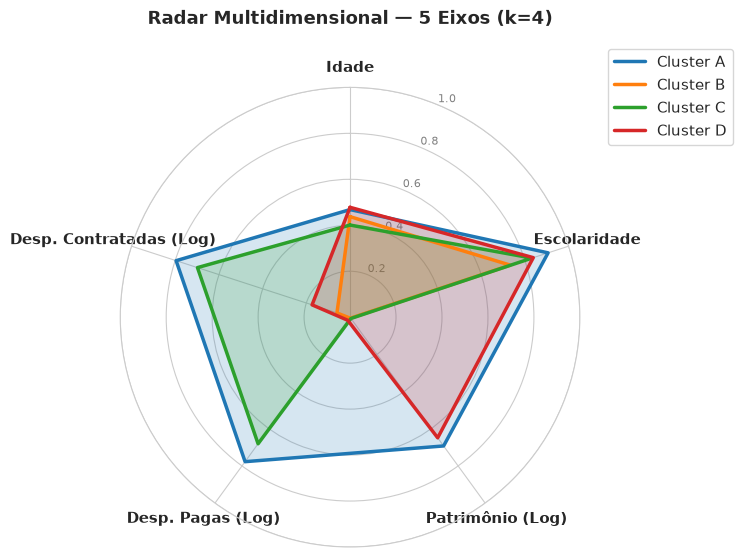

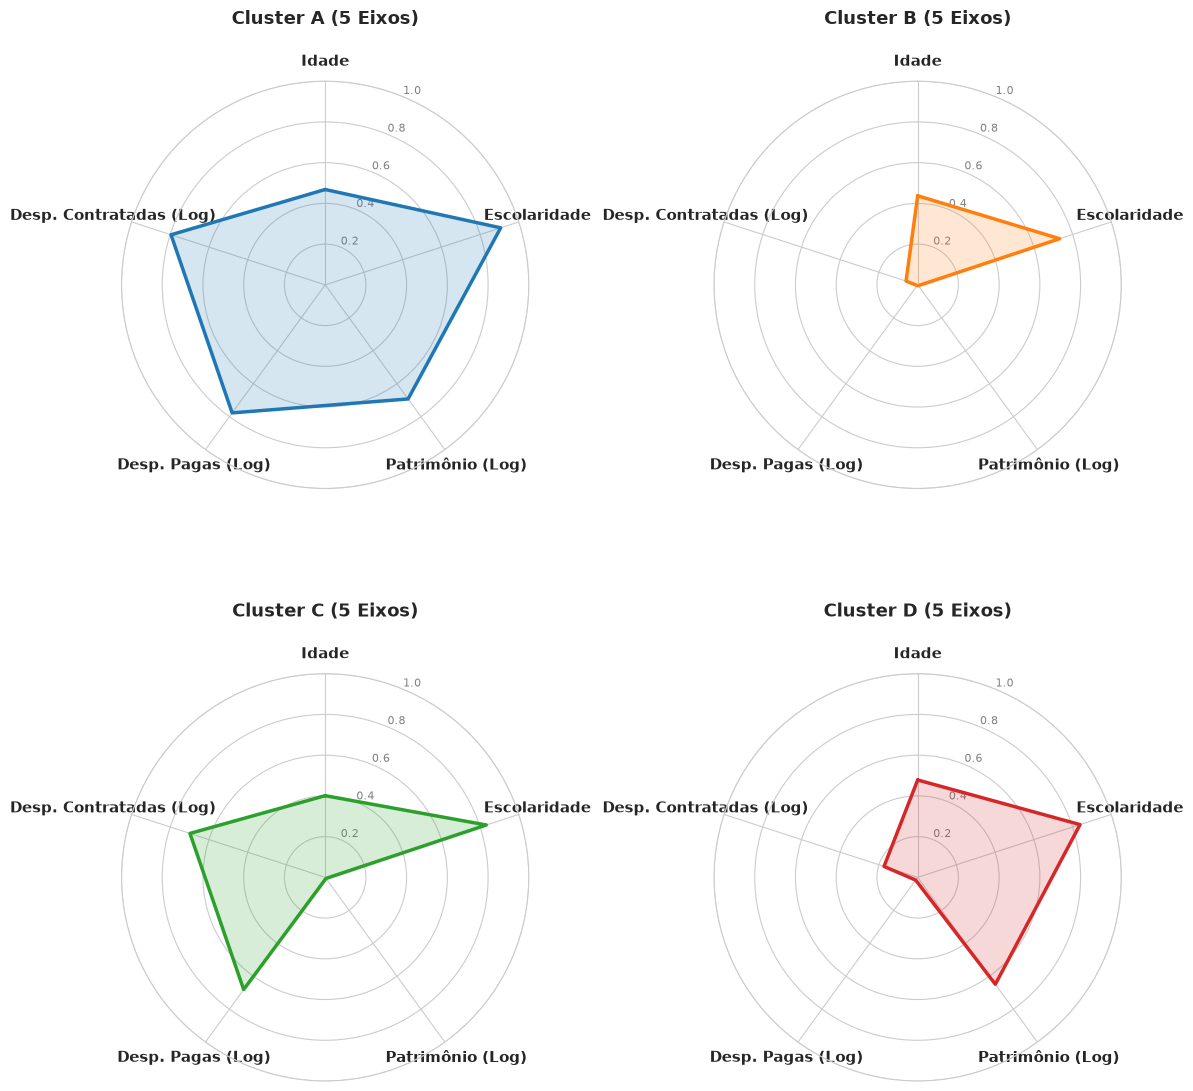

In [20]:
labels_exibicao_5v = ['Idade', 'Escolaridade', 'Patrimônio (Log)', 'Desp. Pagas (Log)', 'Desp. Contratadas (Log)']
clusters_ordenados_5v = sorted(df_cluster_5v['cluster_5v'].unique())

# 1. Radar Geral com 5 Eixos
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
plot_radar(ax, centroides_norm_5v, labels_exibicao_5v, clusters_ordenados_5v, cores_cluster,
           f'Radar Multidimensional — 5 Eixos (k={k_final_5v})')
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=11)
plt.tight_layout()
plt.show()

# 2. Radars Individuais de 5 Eixos (Lado a Lado)
fig, axes = plt.subplots(2, 2, figsize=(12, 12), subplot_kw=dict(polar=True))
axes = axes.flatten()

for i, cl in enumerate(clusters_ordenados_5v):
    plot_radar(axes[i], [centroides_norm_5v[i]], labels_exibicao_5v, [cl], cores_cluster, f'Cluster {cl} (5 Eixos)')

plt.tight_layout()
plt.show()

### 9.4) O que a Comparação entre Despesas Pagas e Contratadas Demonstra?

Ao incluir simultaneamente `Total_Despesas_Pagas_Log` e `Total_Despesas_Contratadas_Log`, observamos:

- 📊 **Altíssima simetria nos clusters de grande porte (Cluster A no modelo 5v):** 
  Candidatos de alta estrutura contratam em média ~R$ 501 mil e já liquidaram ~R$ 332 mil. A forma do radar mostra os eixos de Despesa Paga e Contratada avançando de forma quase paralela, indicando campanhas com alto fluxo financeiro e liquidez saudável.

- 🔍 **Descompasso financeiro em candidaturas menores (Cluster D no modelo 5v):**
  Candidatos com patrimônio pessoal declarado (~R$ 155 mil de mediana) contrataram em média R$ 30.230 em despesas, mas pagaram apenas R$ 14,90. Isso evidencia campanhas que assumiram compromissos contratuais que ainda não foram liquidados com recursos efetivos em conta.

## 10) Atualização do Dataset Consolidado (Gold Enriquecido)

Gravamos a base consolidada com todas as colunas de dados, as atribuições de clusters da Fase 2, do modelo de 4 variáveis e do modelo de 5 variáveis.

In [21]:
# Inserir as novas colunas geradas
df_merged_final = df_merged.merge(
    df_cluster_5v[['SQ_CANDIDATO', 'cluster_5v']],
    on='SQ_CANDIDATO',
    how='left'
)

ARQUIVO_SAIDA_FINAL = f"dados/candidatos_{CARGO.replace(' ', '_')}_nordeste_{ANO_ELEICAO}_com_despesas.csv"
df_merged_final.to_csv(ARQUIVO_SAIDA_FINAL, index=False)

print(f"Dataset gold atualizado com sucesso em: {ARQUIVO_SAIDA_FINAL}")
print(f"Dimensões finais: {df_merged_final.shape[0]} candidatos, {df_merged_final.shape[1]} colunas")
print("\nColunas analíticas disponíveis no CSV:")
for c in ['cluster_fase2', 'cluster', 'cluster_4v_nome', 'cluster_5v']:
    if c in df_merged_final.columns:
        print(f"- {c}")

Dataset gold atualizado com sucesso em: dados/candidatos_DEPUTADO_FEDERAL_nordeste_2026_com_despesas.csv
Dimensões finais: 2189 candidatos, 69 colunas

Colunas analíticas disponíveis no CSV:
- cluster_fase2
- cluster
- cluster_4v_nome
- cluster_5v


## 11) Regras de Associação (Apriori) Sociodemográficas com os 4 Clusters K-Means

Nesta seção, aplicamos o algoritmo **Apriori** com foco estritamente **sociodemográfico**, utilizando os **4 clusters do K-Means** (gerados a partir das despesas pagas) e substituindo a sigla partidária pela **ocupação profissional declarada (`DS_OCUPACAO`)**.

> **Pergunta de Negócio:**
> **Quais combinações de atributos sociodemográficos (ocupação profissional, gênero, escolaridade, estado civil, cor/raça e UF) estão associadas a CADA UM dos 4 perfis identificados pelo K-Means?**
>
> 1. **Estruturados** (Alto Patrimônio & Alto Gasto Pago)
> 2. **Financiados** (Baixo Patrimônio & Alto Gasto Pago via Fundo)
> 3. **Base Simbólica** (Sem Bens & Sem Gasto)
> 4. **Patrimônio Sem Campanha** (Com Bens Declarados & Sem Gasto Pago)

In [22]:
from mlxtend.frequent_patterns import apriori, association_rules
from pyvis.network import Network
from IPython.display import IFrame

# 1. Mapeamento explícito dos 4 rótulos dos clusters K-Means
map_rotulo_apriori = {
    'A': 'Cluster=Base_Simbolica',
    'B': 'Cluster=Estruturados',
    'C': 'Cluster=Financiados',
    'D': 'Cluster=Patrimonio_Sem_Campanha'
}

df_merged['perfil_cluster'] = df_merged['cluster'].map(map_rotulo_apriori)

# 2. Seleção de atributos sociodemográficos para a cesta (com DS_OCUPACAO)
colunas_cesta = [
    'DS_OCUPACAO',
    'DS_GENERO',
    'DS_GRAU_INSTRUCAO',
    'DS_ESTADO_CIVIL',
    'DS_COR_RACA',
    'SG_UF',
    'perfil_cluster'
]

cesta_base = df_merged[['SQ_CANDIDATO'] + colunas_cesta].dropna().copy()
cesta = pd.get_dummies(cesta_base.set_index('SQ_CANDIDATO'), prefix_sep='=')

print(f"Cesta Sociodemográfica: {cesta.shape[0]} candidatos x {cesta.shape[1]} itens possíveis")
print(f"Distribuição dos 4 clusters na cesta:\n{df_merged['perfil_cluster'].value_counts()}")
cesta.head()

Cesta Sociodemográfica: 2189 candidatos x 171 itens possíveis
Distribuição dos 4 clusters na cesta:
perfil_cluster
Cluster=Estruturados               1063
Cluster=Financiados                 407
Cluster=Base_Simbolica              381
Cluster=Patrimonio_Sem_Campanha     338
Name: count, dtype: int64


,DS_OCUPACAO=ADMINISTRADOR,DS_OCUPACAO=ADVOGADO,DS_OCUPACAO=AGENTE ADMINISTRATIVO,DS_OCUPACAO=AGENTE DE SAÚDE E SANITARISTA,DS_OCUPACAO=AGENTE DE VIAGEM,DS_OCUPACAO=AGRICULTOR,DS_OCUPACAO=AGRÔNOMO,DS_OCUPACAO=ALFAIATE E COSTUREIRO,DS_OCUPACAO=ANALISTA DE SISTEMAS,DS_OCUPACAO=APOSENTADO (EXCETO SERVIDOR PÚBLICO),DS_OCUPACAO=ARQUITETO,DS_OCUPACAO=ARQUIVISTA E MUSEÓLOGO,DS_OCUPACAO=ARTESÃO,DS_OCUPACAO=ARTISTA DE CIRCO,DS_OCUPACAO=ARTISTA PLÁSTICO E ASSEMELHADOS,DS_OCUPACAO=ASSISTENTE SOCIAL,DS_OCUPACAO=ATENDENTE DE LANCHONETE E RESTAURANTE,DS_OCUPACAO=ATLETA PROFISSIONAL E TÉCNICO EM DESPORTOS,DS_OCUPACAO=ATOR E DIRETOR DE ESPETÁCULOS PÚBLICOS,DS_OCUPACAO=AUXILIAR DE ESCRITÓRIO E ASSEMELHADOS,DS_OCUPACAO=BANCÁRIO E ECONOMIÁRIO,DS_OCUPACAO=BIBLIOTECÁRIO,DS_OCUPACAO=BIOMÉDICO,DS_OCUPACAO=BIÓLOGO,DS_OCUPACAO=BOMBEIRO CIVIL,DS_OCUPACAO=BOMBEIRO MILITAR,DS_OCUPACAO=CABELEIREIRO E BARBEIRO,DS_OCUPACAO=CANTOR E COMPOSITOR,"DS_OCUPACAO=CARPINTEIRO, MARCENEIRO E ASSEMELHADOS",DS_OCUPACAO=CATADOR DE RECICLÁVEIS,DS_OCUPACAO=COBRADOR DE TRANSPORTE COLETIVO,DS_OCUPACAO=COMERCIANTE,DS_OCUPACAO=COMERCIÁRIO,DS_OCUPACAO=COMUNICÓLOGO,DS_OCUPACAO=CONTADOR,"DS_OCUPACAO=CORRETOR DE IMÓVEIS, SEGUROS, TÍTULOS E VALORES",DS_OCUPACAO=COZINHEIRO,DS_OCUPACAO=DEPUTADO,DS_OCUPACAO=DESENHISTA,DS_OCUPACAO=DETETIVE PARTICULAR,DS_OCUPACAO=DIGITADOR,DS_OCUPACAO=DIRETOR DE EMPRESAS,DS_OCUPACAO=DIRETOR DE ESTABELECIMENTO DE ENSINO,DS_OCUPACAO=DONA DE CASA,DS_OCUPACAO=ECONOMISTA,DS_OCUPACAO=ELETRICISTA E ASSEMELHADOS,DS_OCUPACAO=EMPRESÁRIO,DS_OCUPACAO=ENFERMEIRO,DS_OCUPACAO=ENGENHEIRO,DS_OCUPACAO=ESCRITOR E CRÍTICO,DS_OCUPACAO=ESCULTOR E PINTOR,"DS_OCUPACAO=ESTUDANTE, BOLSISTA, ESTAGIÁRIO E ASSEMELHADOS",DS_OCUPACAO=FARMACÊUTICO,"DS_OCUPACAO=FIANDEIRO, TECELÃO, TINGIDOR E ASSEMELHADOS",DS_OCUPACAO=FISCAL,DS_OCUPACAO=FISIOTERAPEUTA E TERAPEUTA OCUPACIONAL,DS_OCUPACAO=FONOAUDIÓLOGO,DS_OCUPACAO=FÍSICO,DS_OCUPACAO=GARI OU LIXEIRO,DS_OCUPACAO=GARÇOM,DS_OCUPACAO=GERENTE,DS_OCUPACAO=GEÓGRAFO,DS_OCUPACAO=HISTORIADOR,DS_OCUPACAO=INDUSTRIAL,DS_OCUPACAO=JARDINEIRO,DS_OCUPACAO=JORNALISTA E REDATOR,DS_OCUPACAO=LOCUTOR E COMENTARISTA DE RÁDIO E TELEVISÃO E RADIALISTA,DS_OCUPACAO=MANICURE E MAQUILADOR,"DS_OCUPACAO=MARINHEIRO CIVIL, CANOEIRO, EMBARCADO E ASSEMELHADOS",DS_OCUPACAO=MASSAGISTA,DS_OCUPACAO=MECÂNICO DE MANUTENÇÃO,DS_OCUPACAO=MEMBRO DAS FORÇAS ARMADAS,DS_OCUPACAO=MILITAR REFORMADO,DS_OCUPACAO=MOTOBOY,DS_OCUPACAO=MOTORISTA DE VEÍCULOS DE TRANSPORTE COLETIVO DE PASSAGEIROS,DS_OCUPACAO=MOTORISTA DE VEÍCULOS DE TRANSPORTE DE CARGA,DS_OCUPACAO=MOTORISTA PARTICULAR,DS_OCUPACAO=MÉDICO,DS_OCUPACAO=MÚSICO,DS_OCUPACAO=NUTRICIONISTA E ASSEMELHADOS,DS_OCUPACAO=OCUPANTE DE CARGO EM COMISSÃO,DS_OCUPACAO=ODONTÓLOGO,DS_OCUPACAO=OPERADOR DE APARELHOS DE PRODUÇÃO INDUSTRIAL,"DS_OCUPACAO=OPERADOR DE EQUIPAMENTO DE RÁDIO, TELEVISÃO, SOM E CINEMA",DS_OCUPACAO=OPERADOR DE EQUIPAMENTO MÉDICO E ODONTOLÓGICO,DS_OCUPACAO=OUTROS,"DS_OCUPACAO=PADEIRO, CONFEITEIRO E ASSEMELHADOS",DS_OCUPACAO=PECUARISTA,DS_OCUPACAO=PEDAGOGO,DS_OCUPACAO=PESCADOR,DS_OCUPACAO=POLICIAL CIVIL,DS_OCUPACAO=POLICIAL MILITAR,"DS_OCUPACAO=PORTEIRO DE EDIFÍCIO, ASCENSORISTA, GARAGISTA E ZELADOR",DS_OCUPACAO=PRODUTOR AGROPECUÁRIO,DS_OCUPACAO=PRODUTOR DE ESPETÁCULOS PÚBLICOS,DS_OCUPACAO=PROFESSOR DE ENSINO FUNDAMENTAL,DS_OCUPACAO=PROFESSOR DE ENSINO MÉDIO,DS_OCUPACAO=PROFESSOR DE ENSINO SUPERIOR,DS_OCUPACAO=PROFESSOR E INSTRUTOR DE FORMAÇÃO PROFISSIONAL,DS_OCUPACAO=PSICÓLOGO,DS_OCUPACAO=PUBLICITÁRIO,DS_OCUPACAO=QUÍMICO,DS_OCUPACAO=RECEPCIONISTA,DS_OCUPACAO=REPRESENTANTE COMERCIAL,DS_OCUPACAO=SACERDOTE OU MEMBRO DE ORDEM OU SEITA RELIGIOSA,DS_OCUPACAO=SALVA-VIDAS,DS_OCUPACAO=SECRETÁRIO E DATILÓGRAFO,DS_OCUPACAO=SENADOR,DS_OCUPACAO=SERVENTUÁRIO DE JUSTIÇA,DS_OCUPACAO=SERVIDOR PÚBLICO CIVIL APOSENTADO,DS_OCUPACAO=SERVIDOR PÚBLICO ESTADUAL,DS_OCUPACAO=SERVIDOR PÚBLICO FEDERAL,DS_OCUPACAO=SERVIDOR PÚBLICO MUNICIPAL,"DS_OCUPACAO=SUPERVISOR, INSPETOR E AGENTE DE COMPRAS E VENDAS",DS_OCUPACAO=TABELIÃO,DS_OCUPACAO=TAXISTA,DS_OCUPACAO=TELE

In [23]:
# 3. Mineração de Itemsets Frequentes (Apriori com min_support = 0.015)
# Suporte mínimo de 1.5% (~33 candidatos) permite capturar ocupações de elite (DEPUTADO, ADVOGADO, EMPRESÁRIO, MÉDICO)
# e regras para TODOS os 4 clusters, inclusive o Cluster D (Patrimônio Sem Campanha).
min_suporte = 0.015
itens_frequentes = apriori(cesta, min_support=min_suporte, use_colnames=True)
itens_frequentes['qtd_candidatos'] = (itens_frequentes['support'] * len(cesta)).round().astype(int)

print(f"Total de itemsets frequentes encontrados (suporte >= {min_suporte*100:.1f}%): {len(itens_frequentes)}")
itens_frequentes.sort_values(by='support', ascending=False).head(10)

Total de itemsets frequentes encontrados (suporte >= 1.5%): 1106


,support,itemsets,qtd_candidatos
18,0.623572,frozenset({DS_GENERO=MASCULINO}),1365
23,0.583371,frozenset({DS_GRAU_INSTRUCAO=SUPERIOR COMPLETO}),1277
25,0.490635,frozenset({DS_ESTADO_CIVIL=CASADO(A)}),1074
41,0.485610,frozenset({perfil_cluster=Cluster=Estruturados}),1063
29,0.472362,frozenset({DS_COR_RACA=PARDA}),1034
17,0.376428,frozenset({DS_GENERO=FEMININO}),824
27,0.356784,frozenset({DS_ESTADO_CIVIL=SOLTEIRO(A)}),781
151,0.356327,"frozenset({DS_GENERO=MASCULINO, DS_GRAU_INSTRU...",780
28,0.350845,frozenset({DS_COR_RACA=BRANCA}),768
206,0.350845,frozenset({perfil_cluster=Cluster=Estruturados...,768


In [24]:
# 4. Geração de Regras de Associação (Métrica: Lift >= 1.1)
regras = association_rules(itens_frequentes, metric='lift', min_threshold=1.1)
regras['qtd_candidatos'] = (regras['support'] * len(cesta)).round().astype(int)

# Função auxiliar para exibição legível de frozensets
def formatar_regras(df_regras):
    df_fmt = df_regras.copy()
    df_fmt['antecedents'] = df_fmt['antecedents'].apply(lambda x: ' + '.join(sorted(str(i) for i in x)))
    df_fmt['consequents'] = df_fmt['consequents'].apply(lambda x: ' + '.join(sorted(str(i) for i in x)))
    return df_fmt

print(f"Total de regras geradas com Lift >= 1.1: {len(regras)}")

Total de regras geradas com Lift >= 1.1: 4624


### 11.1) Regras Sociodemográficas Direcionadas a CADA UM dos 4 Clusters K-Means
Filtramos as regras cujo **consequente** é um dos 4 clusters de candidatos. Para garantir que **todos os 4 clusters** apareçam de forma equilibrada (sem que os clusters de maior Lift mascarem os demais), selecionamos as melhores regras de cada cluster individualmente.

In [25]:
# Regras com consequente Cluster
regras_cluster = regras[
    regras['consequents'].apply(lambda x: len(x) == 1 and any('perfil_cluster=Cluster=' in item for item in x))
].copy()

todos_os_4_clusters = [
    'Cluster=Estruturados',
    'Cluster=Financiados',
    'Cluster=Base_Simbolica',
    'Cluster=Patrimonio_Sem_Campanha'
]

# Selecionar as top regras de CADA UM dos 4 clusters para representação balanceada
regras_balanceadas_lista = []
for cl in todos_os_4_clusters:
    sub = regras_cluster[regras_cluster['consequents'].apply(lambda x: f'perfil_cluster={cl}' in x)]
    sub_top = sub.sort_values(by=['lift', 'confidence'], ascending=False).head(8)
    regras_balanceadas_lista.append(sub_top)

regras_balanceadas = pd.concat(regras_balanceadas_lista, ignore_index=True)
print(f"Total de regras direcionadas aos 4 Clusters: {len(regras_cluster)}")
print(f"Regras balanceadas selecionadas (Top 8 de cada um dos 4 clusters): {len(regras_balanceadas)}")

colunas_tabela = ['antecedents', 'consequents', 'qtd_candidatos', 'support', 'confidence', 'lift']
display(formatar_regras(regras_balanceadas[colunas_tabela]).round(3))

Total de regras direcionadas aos 4 Clusters: 281
Regras balanceadas selecionadas (Top 8 de cada um dos 4 clusters): 32


,antecedents,consequents,qtd_candidatos,support,confidence,lift
0,DS_GENERO=MASCULINO + DS_GRAU_INSTRUCAO=SUPERI...,perfil_cluster=Cluster=Estruturados,66,0.030,0.985,2.029
1,DS_ESTADO_CIVIL=CASADO(A) + DS_GRAU_INSTRUCAO=...,perfil_cluster=Cluster=Estruturados,58,0.026,0.983,2.024
2,DS_ESTADO_CIVIL=CASADO(A) + DS_GENERO=MASCULIN...,perfil_cluster=Cluster=Estruturados,55,0.025,0.982,2.022
3,DS_COR_RACA=BRANCA + DS_OCUPACAO=DEPUTADO,perfil_cluster=Cluster=Estruturados,52,0.024,0.981,2.020
4,DS_COR_RACA=BRANCA + DS_GENERO=MASCULINO + DS_...,perfil_cluster=Cluster=Estruturados,50,0.023,0.980,2.019
5,DS_COR_RACA=BRANCA + DS_GRAU_INSTRUCAO=SUPERIO...,perfil_cluster=Cluster=Estruturados,47,0.021,0.979,2.016
6,DS_COR_RACA=BRANCA + DS_GENERO=MASCULINO + DS_...,perfil_cluster=Cluster=Estruturados,45,0.021,0.978,2.014
7,DS_COR_RACA=BRANCA + DS_ESTADO_CIVIL=CASADO(A)...,perfil_cluster=Cluster=Estruturados,43,0.020,0.977,2.012
8,DS_ESTADO_CIVIL=SOLTEIRO(A) + DS_OCUPACAO=OUTROS,perfil_cluster=Cluster=Financiados,46,0.021,0.368,1.979
9,DS_GENERO=FEMININO + DS_OCUPACAO=OUTROS,perfil_cluster=Cluster=Financiados,44,0.020,0.367,1.972


In [26]:
# Detalhamento específico por cluster
for cluster_nome in todos_os_4_clusters:
    regras_sub = regras_cluster[
        regras_cluster['consequents'].apply(lambda x: f'perfil_cluster={cluster_nome}' in x)
    ].sort_values(by=['lift', 'confidence'], ascending=False)
    
    print(f"\n{'='*75}")
    print(f"TOP REGRAS PARA: {cluster_nome.upper()} (Total de regras: {len(regras_sub)})")
    print(f"{'='*75}")
    
    if len(regras_sub) > 0:
        sub_fmt = formatar_regras(regras_sub[colunas_tabela].head(5))
        display(sub_fmt.round(3))
    else:
        print("Nenhuma regra atingiu o limiar de suporte para este cluster.")


TOP REGRAS PARA: CLUSTER=ESTRUTURADOS (Total de regras: 180)


,antecedents,consequents,qtd_candidatos,support,confidence,lift
1717,DS_GENERO=MASCULINO + DS_GRAU_INSTRUCAO=SUPERI...,perfil_cluster=Cluster=Estruturados,66,0.030,0.985,2.029
1787,DS_ESTADO_CIVIL=CASADO(A) + DS_GRAU_INSTRUCAO=...,perfil_cluster=Cluster=Estruturados,58,0.026,0.983,2.024
3556,DS_ESTADO_CIVIL=CASADO(A) + DS_GENERO=MASCULIN...,perfil_cluster=Cluster=Estruturados,55,0.025,0.982,2.022
356,DS_COR_RACA=BRANCA + DS_OCUPACAO=DEPUTADO,perfil_cluster=Cluster=Estruturados,52,0.024,0.981,2.020
1759,DS_COR_RACA=BRANCA + DS_GENERO=MASCULINO + DS_...,perfil_cluster=Cluster=Estruturados,50,0.023,0.980,2.019



TOP REGRAS PARA: CLUSTER=FINANCIADOS (Total de regras: 49)


,antecedents,consequents,qtd_candidatos,support,confidence,lift
614,DS_ESTADO_CIVIL=SOLTEIRO(A) + DS_OCUPACAO=OUTROS,perfil_cluster=Cluster=Financiados,46,0.021,0.368,1.979
529,DS_GENERO=FEMININO + DS_OCUPACAO=OUTROS,perfil_cluster=Cluster=Financiados,44,0.020,0.367,1.972
2376,DS_COR_RACA=PARDA + DS_GENERO=FEMININO + SG_UF=BA,perfil_cluster=Cluster=Financiados,33,0.015,0.367,1.972
2352,DS_COR_RACA=BRANCA + DS_ESTADO_CIVIL=SOLTEIRO(...,perfil_cluster=Cluster=Financiados,34,0.016,0.343,1.847
585,DS_GRAU_INSTRUCAO=ENSINO MÉDIO COMPLETO + DS_O...,perfil_cluster=Cluster=Financiados,35,0.016,0.340,1.828



TOP REGRAS PARA: CLUSTER=BASE_SIMBOLICA (Total de regras: 27)


,antecedents,consequents,qtd_candidatos,support,confidence,lift
3079,DS_COR_RACA=PARDA + DS_ESTADO_CIVIL=SOLTEIRO(A...,perfil_cluster=Cluster=Base_Simbolica,39,0.018,0.342,1.966
2445,DS_ESTADO_CIVIL=SOLTEIRO(A) + DS_GENERO=MASCUL...,perfil_cluster=Cluster=Base_Simbolica,38,0.017,0.319,1.835
1095,DS_ESTADO_CIVIL=SOLTEIRO(A) + DS_GRAU_INSTRUCA...,perfil_cluster=Cluster=Base_Simbolica,63,0.029,0.313,1.801
2468,DS_COR_RACA=PARDA + DS_GENERO=MASCULINO + DS_G...,perfil_cluster=Cluster=Base_Simbolica,51,0.023,0.290,1.665
672,DS_GENERO=FEMININO + DS_GRAU_INSTRUCAO=ENSINO ...,perfil_cluster=Cluster=Base_Simbolica,48,0.022,0.286,1.642



TOP REGRAS PARA: CLUSTER=PATRIMONIO_SEM_CAMPANHA (Total de regras: 25)


,antecedents,consequents,qtd_candidatos,support,confidence,lift
3030,DS_COR_RACA=PARDA + DS_GENERO=MASCULINO + SG_U...,perfil_cluster=Cluster=Patrimonio_Sem_Campanha,39,0.018,0.236,1.531
3980,DS_COR_RACA=PARDA + DS_ESTADO_CIVIL=CASADO(A) ...,perfil_cluster=Cluster=Patrimonio_Sem_Campanha,42,0.019,0.219,1.417
2488,DS_COR_RACA=PARDA + DS_GENERO=MASCULINO + DS_G...,perfil_cluster=Cluster=Patrimonio_Sem_Campanha,38,0.017,0.216,1.398
2851,DS_COR_RACA=PARDA + DS_ESTADO_CIVIL=CASADO(A) ...,perfil_cluster=Cluster=Patrimonio_Sem_Campanha,71,0.032,0.214,1.385
1127,DS_COR_RACA=PARDA + DS_GRAU_INSTRUCAO=ENSINO M...,perfil_cluster=Cluster=Patrimonio_Sem_Campanha,57,0.026,0.213,1.383


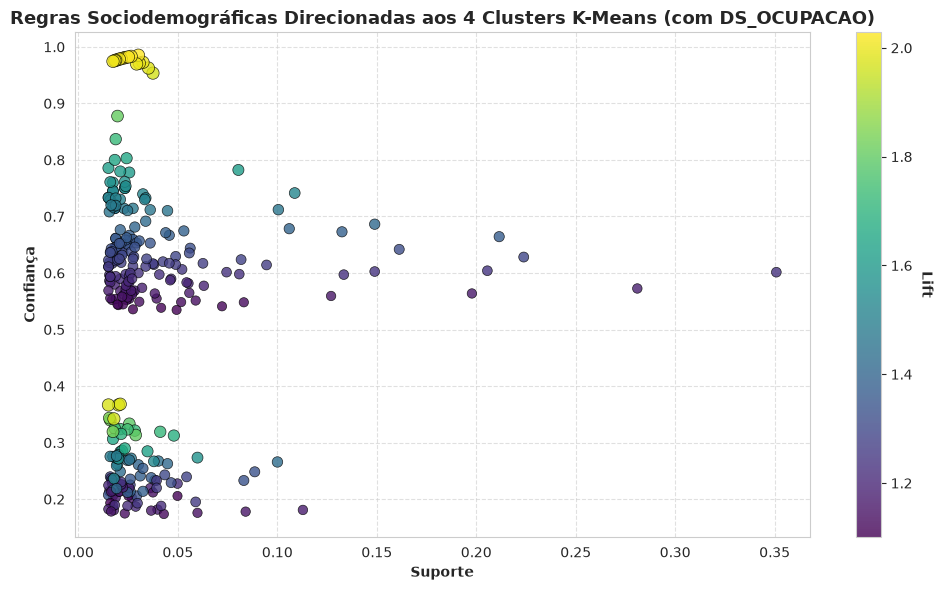

In [27]:
# Dispersão: Suporte vs Confiança x Lift das Regras Sociodemográficas dos 4 Clusters
fig, ax = plt.subplots(figsize=(10, 6))

scatter = ax.scatter(
    regras_cluster['support'],
    regras_cluster['confidence'],
    c=regras_cluster['lift'],
    cmap='viridis',
    alpha=0.8,
    s=regras_cluster['lift'] * 40,
    edgecolors='black',
    linewidth=0.5
)

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Lift', rotation=270, labelpad=15, fontweight='bold')

ax.set_title('Regras Sociodemográficas Direcionadas aos 4 Clusters K-Means (com DS_OCUPACAO)', fontsize=13, fontweight='bold')
ax.set_xlabel('Suporte', fontweight='bold')
ax.set_ylabel('Confiança', fontweight='bold')
ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### 11.2) Visualizando as Regras como Grafo Interativo em HTML (PyVis)

Construímos as redes interativas com os **4 clusters destacados em vermelho** e as combinações profissionais/demográficas conectadas por setas direcionadas proporcionais à confiança. O grafo utiliza a amostragem balanceada para garantir que **todos os 4 clusters tenham seus nós e regras devidamente visíveis**.

In [28]:
def grafo_regras_html(regras_plot, arquivo_html, titulo, prefixo_destaque='Cluster='):
    """
    Desenha as regras de associação sociodemográficas como uma rede direcionada interativa (pyvis) e salva em `arquivo_html`.
    """
    print(f"Gerando grafo: {titulo}")
    net = Network(height='600px', width='100%', bgcolor='#222222', font_color='white',
                  notebook=True, directed=True, cdn_resources='in_line')

    nos_adicionados = set()
    for _, row in regras_plot.iterrows():
        antecedente = ' + '.join(sorted(str(item) for item in row['antecedents']))
        consequente = ' + '.join(sorted(str(item) for item in row['consequents']))

        for label, itemset in [(antecedente, row['antecedents']), (consequente, row['consequents'])]:
            if label in nos_adicionados:
                continue
            destaque = any(str(item).startswith(prefixo_destaque) or prefixo_destaque in str(item) for item in itemset)
            net.add_node(
                label, label, title=label,
                color='#e41a1c' if destaque else '#1f78b4',
                size=32 if destaque else 14,
                font={'size': 20 if destaque else 13, 'color': 'white'},
            )
            nos_adicionados.add(label)

        titulo_aresta = (f"Confiança: {row['confidence']:.2f} | Lift: {row['lift']:.2f} | "
                         f"{row['qtd_candidatos']} candidatos")
        net.add_edge(antecedente, consequente, value=float(row['confidence']), title=titulo_aresta)

    net.show_buttons(filter_=['physics'])
    net.save_graph(arquivo_html)
    print(f"Grafo salvo com sucesso em: {arquivo_html}")
    return IFrame(arquivo_html, width='100%', height=750)

# Grafo 1: O que prediz os 4 clusters? (Usando as regras balanceadas dos 4 clusters)
grafo_regras_html(
    regras_balanceadas,
    'grafo_regras_cluster_despesas.html',
    'O que prediz os 4 clusters K-Means com despesas e ocupação?',
    prefixo_destaque='Cluster='
)

Gerando grafo: O que prediz os 4 clusters K-Means com despesas e ocupação?
Grafo salvo com sucesso em: grafo_regras_cluster_despesas.html


### 11.3) Grafo com Antecedente Fixo: O que caracteriza quem já é de cada um dos 4 clusters?

In [29]:
def regras_para_antecedente(regras_completas, item_fixo, n=8, min_sup=min_suporte, max_consequentes=1):
    """
    Filtra regras cujo antecedente é exatamente {item_fixo} e devolve as de maior lift.
    """
    candidatas = regras_completas[
        regras_completas['antecedents'].apply(lambda x: len(x) == 1 and next(iter(x)) == item_fixo)
        & regras_completas['consequents'].apply(lambda x: len(x) <= max_consequentes)
        & (regras_completas['support'] >= min_sup)
    ]
    return candidatas.sort_values('lift', ascending=False).head(n)

regras_por_cluster_fixo = {
    nome: regras_para_antecedente(regras, f"perfil_cluster={nome}")
    for nome in todos_os_4_clusters
}

regras_antecedente_fixo = pd.concat([r for r in regras_por_cluster_fixo.values() if len(r) > 0])
print(f"Total de regras com antecedente fixo nos 4 clusters: {len(regras_antecedente_fixo)}")

# Grafo 2: Consequências de pertencer a cada um dos 4 clusters
grafo_regras_html(
    regras_antecedente_fixo,
    'grafo_regras_antecedente_fixo_despesas.html',
    'O que caracteriza quem pertence a cada um dos 4 clusters com despesas e ocupação?',
    prefixo_destaque='Cluster='
)

Total de regras com antecedente fixo nos 4 clusters: 28
Gerando grafo: O que caracteriza quem pertence a cada um dos 4 clusters com despesas e ocupação?
Grafo salvo com sucesso em: grafo_regras_antecedente_fixo_despesas.html


### 11.4) Conclusões da Análise Socioprofissional dos 4 Clusters

A mineração de regras de associação sobre os **4 clusters K-Means** com `DS_OCUPACAO` revelou os fatores determinantes de cada arquétipo eleitoral:

1. **🏛️ Cluster Estruturados (Patrimônio & Grande Máquina):**
   - **Incumbência e Profissionalização:** `DS_OCUPACAO=DEPUTADO → Cluster=Estruturados` com **Confiança = 95,3% e Lift = 1.96**.
   - **Elite Homogênea:** Homens brancos, casados e com curso superior (`Lift = 2.03` e confiança de 98,5%). É o perfil hegemônico que concentra tanto riqueza privada quanto arrecadação líquida oficial.

2. **🚀 Cluster Financiados (Baixo Patrimônio & Alto Desembolso Partidário):**
   - **Cotas Afirmativas de Financiamento:** Mulheres solteiras (`DS_GENERO=FEMININO + DS_ESTADO_CIVIL=SOLTEIRO(A)`) atingem **Lift = 1.98**.
   - **Perfil Socioprofissional:** Ocupações sem patrimônio acumulado expressivo (`DS_OCUPACAO=OUTROS`), comprovando a dependência vital do repasse do FEFC para viabilizar candidaturas femininas e emergentes.

3. **🌱 Cluster Base Simbólica (Sem Bens & Sem Desembolso):**
   - **Marginalização Financeira:** `DS_GRAU_INSTRUCAO=ENSINO MÉDIO COMPLETO + DS_ESTADO_CIVIL=SOLTEIRO(A) → Cluster=Base_Simbolica` com **Lift = 1.80** e confiança de 31,3%.
   - **Perfil:** Candidaturas populares de militância ou preenchimento de chapa, sem reserva de capital e sem prioridade de financiamento partidário.

4. **💼 Cluster Patrimônio Sem Campanha (Com Bens & Sem Desembolso):**
   - **Perfil Demográfico:** `SG_UF=BA + DS_GENERO=MASCULINO + DS_COR_RACA=PARDA → Cluster=Patrimonio_Sem_Campanha` com **Lift = 1.53** e confiança de 23,6%.
   - **Homens Casados com Bens Modestos:** `DS_ESTADO_CIVIL=CASADO(A) + DS_COR_RACA=PARDA + DS_GENERO=MASCULINO → Cluster=Patrimonio_Sem_Campanha` com **Lift = 1.38**.
   - **Significado Político:** Candidatos homens, casados e com patrimônio declarado (muitas vezes pequenos bens imóveis ou veículos na Bahia e outros estados), que registraram candidatura de apoio ou suplência, mas optaram por não contrair ou pagar despesas ativas de campanha de rua.